# Species-Level Random Forest Analysis

## Objective

Evaluate whether **local environmental conditions** and **Snapshot USA (SSUSA) site-level variables** explain whether a species is observed by SSUSA at camera locations where the species is predicted to occur by IUCN.

### Modeling approach

- **Unit of analysis:** Camera × Species
- **Population:** Camera–species pairs where `iucn_predicted = 1`
- **Response variable:** `ssusa_observed`
  - `1` = species observed by SSUSA
  - `0` = species not observed by SSUSA
- **Environmental predictors:** NLCD land-cover composition and distance to roads
- **SSUSA site predictors:** Survey effort and site characteristics
- **Model:** Random Forest classifier fitted separately for each species

The analysis compares environmental-only, SSUSA site-only, and combined models to deterrmine which factors help explain species detection within their IUCN-predicted ranges.

In [52]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

In [59]:
# --------------------------------------------------
# Define input and output paths
# --------------------------------------------------

OUTPUT_PATH = "../../outputs/species_level_analysis"

# Input datasets
SPECIES_DETECTION_FILE = (
    f"{OUTPUT_PATH}/camera_species_detection.csv"
)

CAMERA_COVARIATES_FILE = (
    f"{OUTPUT_PATH}/camera_covariates.csv"
)

NLCD_COVARIATES_FILE = (
    f"{OUTPUT_PATH}/camera_nlcd_covariates.csv"
)

ROAD_DISTANCE_FILE = (
    f"{OUTPUT_PATH}/camera_road_distance.csv"
)

species_detection = pd.read_csv(SPECIES_DETECTION_FILE)
camera_covariates = pd.read_csv(CAMERA_COVARIATES_FILE)
nlcd_covariates = pd.read_csv(NLCD_COVARIATES_FILE)
road_distance = pd.read_csv(ROAD_DISTANCE_FILE)
rf_base = species_detection[
    species_detection["iucn_predicted"] == 1
].copy()

# Check dataset dimensions
print("All camera-species pairs:", len(species_detection))
print("IUCN range-restricted pairs:", len(rf_base))
print("Camera covariates:", camera_covariates.shape)
print("NLCD covariates:", nlcd_covariates.shape)
print("Road distance:", road_distance.shape)

All camera-species pairs: 484440
IUCN range-restricted pairs: 108913
Camera covariates: (7340, 6)
NLCD covariates: (7263, 7)
Road distance: (7263, 2)


In [60]:
# Verify camera_fp_id uniqueness in covariate datasets
# ------------------------------------------------------------

print(
    "Camera covariates duplicate IDs:",
    camera_covariates["camera_fp_id"].duplicated().sum()
)

print(
    "NLCD covariates duplicate IDs:",
    nlcd_covariates["camera_fp_id"].duplicated().sum()
)

print(
    "Road distance duplicate IDs:",
    road_distance["camera_fp_id"].duplicated().sum()
)

print(
    "\nUnique cameras in RF base:",
    rf_base["camera_fp_id"].nunique()
)

Camera covariates duplicate IDs: 0
NLCD covariates duplicate IDs: 0
Road distance duplicate IDs: 0

Unique cameras in RF base: 7223


### Merge camera/site covariates

In [61]:
# Merge SSUSA camera/site covariates
# ------------------------------------------------------------

rf_dataset = rf_base.merge(
    camera_covariates,
    on="camera_fp_id",
    how="left",
    validate="many_to_one"
)

print("Rows before merge:", len(rf_base))
print("Rows after merge:", len(rf_dataset))

print("\nMissing camera covariates:")
print(
    rf_dataset[
        ["Total_Survey_Nights", "Habitat", "Development_Level"]
    ].isna().sum()
)

Rows before merge: 108913
Rows after merge: 108913

Missing camera covariates:
Total_Survey_Nights    0
Habitat                0
Development_Level      0
dtype: int64



### Merge NLCD environmental covariatesV and distance to primary roads 

In [62]:
# Merge NLCD environmental covariates
# ------------------------------------------------------------

rf_dataset = rf_dataset.merge(
    nlcd_covariates,
    on="camera_fp_id",
    how="left",
    validate="many_to_one"
)

print("Rows after NLCD merge:", len(rf_dataset))

print("\nMissing NLCD covariates:")
print(
    rf_dataset[
        [
            "forest_pct",
            "grassland_pct",
            "wetland_pct",
            "developed_pct",
            "cropland_pct",
            "valid_nlcd_pixels",
        ]
    ].isna().sum()
)

Rows after NLCD merge: 108913

Missing NLCD covariates:
forest_pct           418
grassland_pct        418
wetland_pct          418
developed_pct        418
cropland_pct         418
valid_nlcd_pixels    418
dtype: int64


In [63]:
# ------------------------------------------------------------
# Merge distance to primary road
# ------------------------------------------------------------

rf_dataset = rf_dataset.merge(
    road_distance,
    on="camera_fp_id",
    how="left",
    validate="many_to_one"
)

print("Rows after road-distance merge:", len(rf_dataset))

print(
    "\nMissing road-distance values:",
    rf_dataset["distance_to_primary_road_m"].isna().sum()
)

print(
    "Unique cameras missing road distance:",
    rf_dataset.loc[
        rf_dataset["distance_to_primary_road_m"].isna(),
        "camera_fp_id"
    ].nunique()
)

Rows after road-distance merge: 108913

Missing road-distance values: 418
Unique cameras missing road distance: 42


In [64]:
# Check whether the same cameras are missing NLCD and road data
# ------------------------------------------------------------

missing_nlcd_cameras = set(
    rf_dataset.loc[
        rf_dataset["forest_pct"].isna(),
        "camera_fp_id"
    ]
)

missing_road_cameras = set(
    rf_dataset.loc[
        rf_dataset["distance_to_primary_road_m"].isna(),
        "camera_fp_id"
    ]
)

print("Cameras missing NLCD:", len(missing_nlcd_cameras))
print("Cameras missing road distance:", len(missing_road_cameras))

print(
    "Cameras missing both:",
    len(missing_nlcd_cameras & missing_road_cameras)
)

print(
    "Same set of cameras:",
    missing_nlcd_cameras == missing_road_cameras
)

Cameras missing NLCD: 42
Cameras missing road distance: 42
Cameras missing both: 42
Same set of cameras: True


### Remove records with missing environmental covariates

In [65]:
rows_before = len(rf_dataset)
cameras_before = rf_dataset["camera_fp_id"].nunique()

rf_dataset = rf_dataset.dropna(
    subset=[
        "forest_pct",
        "grassland_pct",
        "wetland_pct",
        "developed_pct",
        "cropland_pct",
        "distance_to_primary_road_m"
    ]
).copy()

print("Rows removed:", rows_before - len(rf_dataset))
print("Rows remaining:", len(rf_dataset))

print("\nCameras removed:", cameras_before - rf_dataset["camera_fp_id"].nunique())
print("Cameras remaining:", rf_dataset["camera_fp_id"].nunique())

Rows removed: 418
Rows remaining: 108495

Cameras removed: 42
Cameras remaining: 7181


### Summarize sample size and class balance by species

In [68]:
# ------------------------------------------------------------
# Summarize response distribution for each species
# ------------------------------------------------------------

species_summary = (
    rf_dataset
    .groupby("species")["ssusa_observed"]
    .agg(
        total_cameras="size",
        observed="sum"
    )
    .reset_index()
)

species_summary["not_observed"] = (
    species_summary["total_cameras"] - species_summary["observed"]
)

species_summary["observed_pct"] = (
    100 * species_summary["observed"] / species_summary["total_cameras"]
)

species_summary = species_summary.sort_values("species").reset_index(drop=True)

print("Number of species:", len(species_summary))

pd.set_option("display.max_rows", None)
display(species_summary)

Number of species: 64


,species,total_cameras,observed,not_observed,observed_pct
0,alces alces,805,101,704,12.546584
1,antilocapra americana,630,119,511,18.888889
2,aplodontia rufa,251,13,238,5.179283
3,bassariscus astutus,1209,21,1188,1.736973
4,canis latrans,7072,3100,3972,43.834842
5,canis lupus,566,94,472,16.607774
6,canis rufus,34,4,30,11.764706
7,cervus elaphus,858,241,617,28.088578
8,conepatus leuconotus,328,15,313,4.573171
9,cynomys gunnisoni,26,0,26,0.000000


### Determine RF-eligible species

For a species-specific RF, the important issue is not just total_cameras; both outcome classes need enough examples. For example, marmota flaviventris has 716 cameras but 0 observations, so there is nothing for a classifier to learn about observed vs. not observed.

In [69]:
# Identify species with sufficient samples in both classes
# ------------------------------------------------------------

MIN_CLASS_SAMPLES = 20

species_summary["rf_eligible"] = (
    (species_summary["observed"] >= MIN_CLASS_SAMPLES) &
    (species_summary["not_observed"] >= MIN_CLASS_SAMPLES)
)

eligible_species = species_summary.loc[
    species_summary["rf_eligible"],
    "species"
].tolist()

print("Minimum samples required per class:", MIN_CLASS_SAMPLES)
print("Total species:", len(species_summary))
print("RF-eligible species:", len(eligible_species))
print("Excluded species:", len(species_summary) - len(eligible_species))

display(
    species_summary[
        ["species", "total_cameras", "observed",
         "not_observed", "observed_pct", "rf_eligible"]
    ]
)

Minimum samples required per class: 20
Total species: 64
RF-eligible species: 40
Excluded species: 24


,species,total_cameras,observed,not_observed,observed_pct,rf_eligible
0,alces alces,805,101,704,12.546584,True
1,antilocapra americana,630,119,511,18.888889,True
2,aplodontia rufa,251,13,238,5.179283,False
3,bassariscus astutus,1209,21,1188,1.736973,True
4,canis latrans,7072,3100,3972,43.834842,True
5,canis lupus,566,94,472,16.607774,True
6,canis rufus,34,4,30,11.764706,False
7,cervus elaphus,858,241,617,28.088578,True
8,conepatus leuconotus,328,15,313,4.573171,False
9,cynomys gunnisoni,26,0,26,0.000000,False


### RF modeling dataset

In [70]:
# Restrict modeling dataset to RF-eligible species
# ------------------------------------------------------------

rf_model_data = rf_dataset[
    rf_dataset["species"].isin(eligible_species)
].copy()

print("RF modeling rows:", len(rf_model_data))
print("Species:", rf_model_data["species"].nunique())
print("Unique cameras:", rf_model_data["camera_fp_id"].nunique())

print("\nOverall response distribution:")
print(rf_model_data["ssusa_observed"].value_counts())

print("\nOverall response proportions:")
print(
    rf_model_data["ssusa_observed"]
    .value_counts(normalize=True)
    .sort_index()
)

RF modeling rows: 101273
Species: 40
Unique cameras: 7181

Overall response distribution:
ssusa_observed
0    74412
1    26861
Name: count, dtype: int64

Overall response proportions:
ssusa_observed
0    0.734766
1    0.265234
Name: proportion, dtype: float64


In [39]:
# Validate the merged Random Forest dataset
# --------------------------------------------------

print("Dataset shape:", rf_dataset.shape)

print("\nUnique cameras:")
print(rf_dataset["camera_fp_id"].nunique())

print("\nUnique species:")
print(rf_dataset["species"].nunique())

print("\nResponse variable distribution:")
print(rf_dataset["ssusa_observed"].value_counts())

print("\nMissing values:")
display(
    rf_dataset.isna().sum()[rf_dataset.isna().sum() > 0]
)

print("\nDuplicate camera-species pairs:")
print(
    rf_dataset.duplicated(
        subset=["camera_fp_id", "species"]
    ).sum()
)

Dataset shape: (370863, 16)

Unique cameras:
7263

Unique species:
66

Response variable distribution:
ssusa_observed
0    368707
1      2156
Name: count, dtype: int64

Missing values:


Series([], dtype: int64)


Duplicate camera-species pairs:
0


### Define Predictor Sets

Three Random Forest models will be evaluated separately for each species:

1. **Environmental model** — local land-cover composition and distance to a primary road.
2. **SSUSA site model** — survey effort and camera-site characteristics recorded by Snapshot USA.
3. **Combined model** — environmental and SSUSA site variables together.

This comparison evaluates whether environmental conditions improve prediction of SSUSA species observations beyond site and survey characteristics alone.

In [71]:
# Define predictor groups
# ------------------------------------------------------------

environmental_features = [
    "forest_pct",
    "grassland_pct",
    "wetland_pct",
    "developed_pct",
    "cropland_pct",
    "distance_to_primary_road_m"
]

ssusa_numeric_features = [
    "Total_Survey_Nights"
]

ssusa_categorical_features = [
    "Habitat",
    "Development_Level"
]

ssusa_features = (
    ssusa_numeric_features +
    ssusa_categorical_features
)

combined_features = (
    environmental_features +
    ssusa_features
)

target = "ssusa_observed"

print("Environmental predictors:", environmental_features)
print("SSUSA site predictors:", ssusa_features)
print("Combined predictors:", combined_features)
print("Target:", target)

Environmental predictors: ['forest_pct', 'grassland_pct', 'wetland_pct', 'developed_pct', 'cropland_pct', 'distance_to_primary_road_m']
SSUSA site predictors: ['Total_Survey_Nights', 'Habitat', 'Development_Level']
Combined predictors: ['forest_pct', 'grassland_pct', 'wetland_pct', 'developed_pct', 'cropland_pct', 'distance_to_primary_road_m', 'Total_Survey_Nights', 'Habitat', 'Development_Level']
Target: ssusa_observed


### Prepare Predictor Preprocessing

Numeric predictors are passed directly to the Random Forest. Categorical SSUSA site variables are converted to one-hot encoded indicator variables so they can be included in the model.

In [72]:
# ------------------------------------------------------------
# Define preprocessing for predictor types
# ------------------------------------------------------------

# Environmental model: all predictors are numeric
environmental_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", environmental_features)
    ]
)

# SSUSA site model:
# survey effort is numeric; site characteristics are categorical
ssusa_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", ssusa_numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ssusa_categorical_features
        )
    ]
)

# Combined model
combined_numeric_features = (
    environmental_features +
    ssusa_numeric_features
)

combined_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", combined_numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ssusa_categorical_features
        )
    ]
)

### Random Forest Configuration and Train/Test Strategy

For each eligible species, the data are split into training and test sets using a stratified split so that the proportion of observed and not-observed cases is preserved in both sets.

Random Forest classifiers use class-balanced weights to reduce bias toward the majority class. Model performance will be evaluated on the held-out test set.

In [73]:
# Random Forest configuration
# ------------------------------------------------------------

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_ESTIMATORS = 500

rf_params = {
    "n_estimators": N_ESTIMATORS,
    "random_state": RANDOM_STATE,
    "class_weight": "balanced",
    "n_jobs": -1
}

print("Test size:", TEST_SIZE)
print("Random state:", RANDOM_STATE)
print("Number of trees:", N_ESTIMATORS)
print("Class weighting:", rf_params["class_weight"])

Test size: 0.2
Random state: 42
Number of trees: 500
Class weighting: balanced


In [82]:
# ------------------------------------------------------------
# Fit and evaluate one species-level Random Forest
# ------------------------------------------------------------
from sklearn.base import clone

def fit_species_rf(
    species_data,
    features,
    preprocessor
):
    X = species_data[features]
    y = species_data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "rf",
                RandomForestClassifier(**rf_params)
            )
        ]
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    metrics = {
        "test_n": len(y_test),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    return model, metrics

### Test the Species-Level Random Forest Workflow

Before fitting models for all eligible species, test the workflow on a single species to verify that preprocessing, model fitting, and evaluation run correctly.

In [83]:
# ------------------------------------------------------------
# Test the workflow on one species
# ------------------------------------------------------------

test_species = "canis latrans"

test_data = rf_model_data[
    rf_model_data["species"] == test_species
].copy()

print("Species:", test_species)
print("Rows:", len(test_data))
print("\nResponse counts:")
print(test_data[target].value_counts())

# Fit combined model
test_model, test_metrics = fit_species_rf(
    species_data=test_data,
    features=combined_features,
    preprocessor=combined_preprocessor
)

print("\nCombined model performance:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value}")

Species: canis latrans
Rows: 7072

Response counts:
ssusa_observed
0    3972
1    3100
Name: count, dtype: int64

Combined model performance:
test_n: 1415
balanced_accuracy: 0.6764404544532359
precision: 0.6468590831918506
recall: 0.614516129032258
f1: 0.630272952853598
roc_auc: 0.7459312233718807
tn: 587
fp: 208
fn: 239
tp: 381


### Fit Combined Random Forest Models for All Eligible Species

Fit a separate Random Forest classifier for each eligible species using the combined environmental and SSUSA site predictors.

Each model predicts whether the species was observed by SSUSA at camera locations within its IUCN-predicted range. Model performance is evaluated on a stratified 20% held-out test set.

In [84]:
# ------------------------------------------------------------
# Fit combined Random Forest for each eligible species
# ------------------------------------------------------------

all_results = []
species_models = {}

for species in eligible_species:

    species_data = rf_model_data[
        rf_model_data["species"] == species
    ].copy()

    model, metrics = fit_species_rf(
        species_data=species_data,
        features=combined_features,
        preprocessor=combined_preprocessor
    )

    # Store trained model for later feature-importance analysis
    species_models[species] = model

    # Store performance metrics
    all_results.append({
        "species": species,
        "total_n": len(species_data),
        "observed_n": int(species_data[target].sum()),
        "not_observed_n": int(
            len(species_data) - species_data[target].sum()
        ),
        **metrics
    })

# Convert results to DataFrame
rf_results = pd.DataFrame(all_results)

# Sort alphabetically by species
rf_results = rf_results.sort_values(
    "species"
).reset_index(drop=True)

print("Species modeled:", len(rf_results))

display(rf_results)

Species modeled: 40


,species,total_n,observed_n,not_observed_n,test_n,balanced_accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,alces alces,805,101,704,161,0.639539,0.411765,0.350000,0.378378,0.818617,131,10,13,7
1,antilocapra americana,630,119,511,126,0.770833,0.500000,0.708333,0.586207,0.854167,85,17,7,17
2,bassariscus astutus,1209,21,1188,242,0.610294,0.125000,0.250000,0.166667,0.966387,231,7,3,1
3,canis latrans,7072,3100,3972,1415,0.676440,0.646859,0.614516,0.630273,0.745931,587,208,239,381
4,canis lupus,566,94,472,114,0.710526,0.423077,0.578947,0.488889,0.831302,80,15,8,11
5,cervus elaphus,858,241,617,172,0.793683,0.693878,0.708333,0.701031,0.890205,109,15,14,34
6,cynomys ludovicianus,703,26,677,141,0.585294,0.200000,0.200000,0.200000,0.917647,132,4,4,1
7,dasypus novemcinctus,2005,796,1209,401,0.706677,0.605263,0.723270,0.659026,0.770934,167,75,44,115
8,didelphis virginiana,5584,1973,3611,1117,0.706895,0.600467,0.650633,0.624544,0.792649,551,171,138,257
9,erethizon dorsatum,2407,116,2291,482,0.634745,0.304348,0.304348,0.304348,0.811973,443,16,16,7


### Summarize Species-Level Model Performance

Summarize predictive performance across species using ROC-AUC, balanced accuracy, precision, recall, and F1 score.

Because species differ substantially in observation prevalence, balanced accuracy and ROC-AUC are emphasized over raw accuracy. Precision, recall, and F1 are retained to evaluate performance for the observed class.

In [85]:
# ------------------------------------------------------------
# Summarize model performance across species
# ------------------------------------------------------------

performance_metrics = [
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

performance_summary = (
    rf_results[performance_metrics]
    .describe()
    .T
)

display(performance_summary)

,count,mean,std,min,25%,50%,75%,max
balanced_accuracy,40.0,0.688694,0.101931,0.482143,0.610112,0.706786,0.775319,0.845536
precision,40.0,0.463857,0.228460,0.000000,0.327586,0.463998,0.611415,0.935514
recall,40.0,0.500022,0.252912,0.000000,0.296837,0.575188,0.702083,0.939906
f1,40.0,0.476042,0.236163,0.000000,0.288901,0.500000,0.641806,0.937705
roc_auc,40.0,0.830226,0.085952,0.604167,0.803283,0.836610,0.888606,0.980804


In [86]:
# ------------------------------------------------------------
# Extract top 3 predictors for each species
# ------------------------------------------------------------
from sklearn.base import clone

importance_results = []

for species, model in species_models.items():

    # Get fitted preprocessing and RF components
    preprocessor = model.named_steps["preprocessor"]
    rf = model.named_steps["rf"]

    # Names of transformed features
    feature_names = preprocessor.get_feature_names_out()

    # RF feature importances
    importances = rf.feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })

    # Map transformed features back to original predictors
    def original_feature(name):

        name = name.replace("numeric__", "")
        name = name.replace("categorical__", "")

        if name.startswith("Habitat_"):
            return "Habitat"

        if name.startswith("Development_Level_"):
            return "Development_Level"

        return name

    importance_df["predictor"] = (
        importance_df["feature"]
        .apply(original_feature)
    )

    # Sum importance across dummy variables belonging
    # to the same original categorical predictor
    predictor_importance = (
        importance_df
        .groupby("predictor", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    # Keep top 3
    top3 = predictor_importance.head(3)

    for rank, row in enumerate(top3.itertuples(), start=1):
        importance_results.append({
            "species": species,
            "rank": rank,
            "predictor": row.predictor,
            "importance": row.importance
        })

top3_predictors = pd.DataFrame(importance_results)

display(top3_predictors)

,species,rank,predictor,importance
0,alces alces,1,distance_to_primary_road_m,0.243442
1,alces alces,2,Total_Survey_Nights,0.170807
2,alces alces,3,forest_pct,0.128649
3,antilocapra americana,1,distance_to_primary_road_m,0.313641
4,antilocapra americana,2,grassland_pct,0.164610
5,antilocapra americana,3,Total_Survey_Nights,0.119237
6,bassariscus astutus,1,Total_Survey_Nights,0.185513
7,bassariscus astutus,2,grassland_pct,0.180775
8,bassariscus astutus,3,distance_to_primary_road_m,0.148960
9,canis latrans,1,Total_Survey_Nights,0.177028


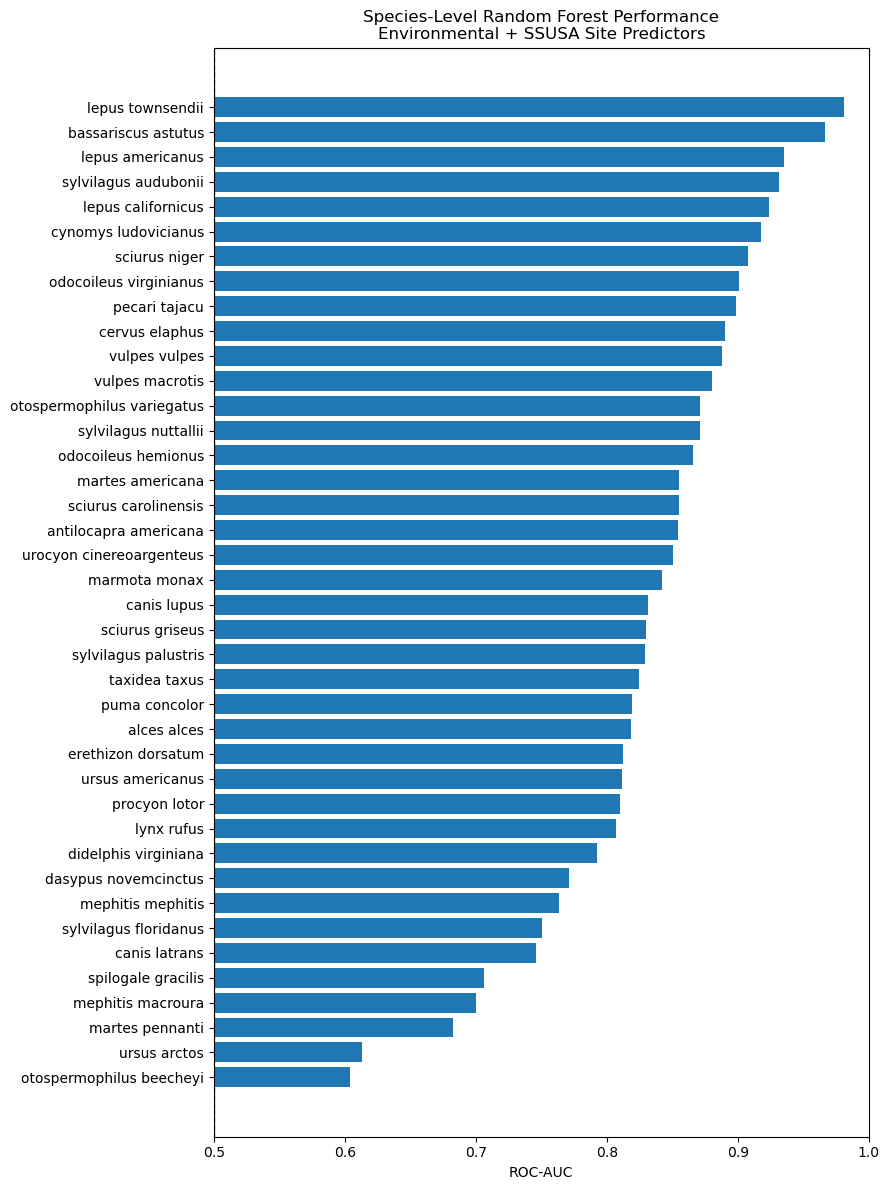

In [94]:
# ------------------------------------------------------------
# Plot ROC-AUC for each species
# ------------------------------------------------------------

plot_df = rf_results.sort_values(
    "roc_auc",
    ascending=True
)

plt.figure(figsize=(9, 12))

plt.barh(
    plot_df["species"],
    plot_df["roc_auc"]
)

# Reference line for random discrimination
plt.axvline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.xlabel("ROC-AUC")
plt.ylabel("")
plt.title(
    "Species-Level Random Forest Performance\n"
    "Environmental + SSUSA Site Predictors"
)

plt.xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

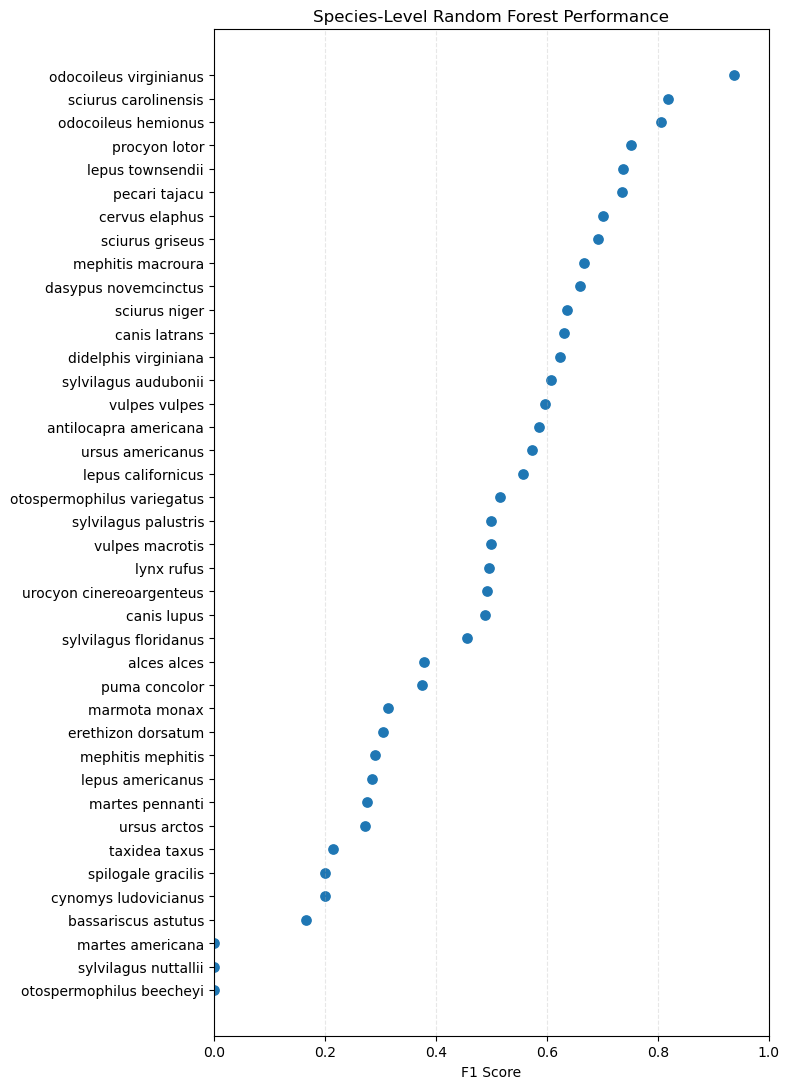

In [96]:
# ------------------------------------------------------------
# Plot F1 score for each species
# ------------------------------------------------------------

plot_df = rf_results.sort_values(
    "f1",
    ascending=True
)

plt.figure(figsize=(8, 11))

plt.scatter(
    plot_df["f1"],
    plot_df["species"],
    s=45
)

plt.xlim(0, 1)

plt.xlabel("F1 Score")
plt.ylabel("")

plt.title(
    "Species-Level Random Forest Performance"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

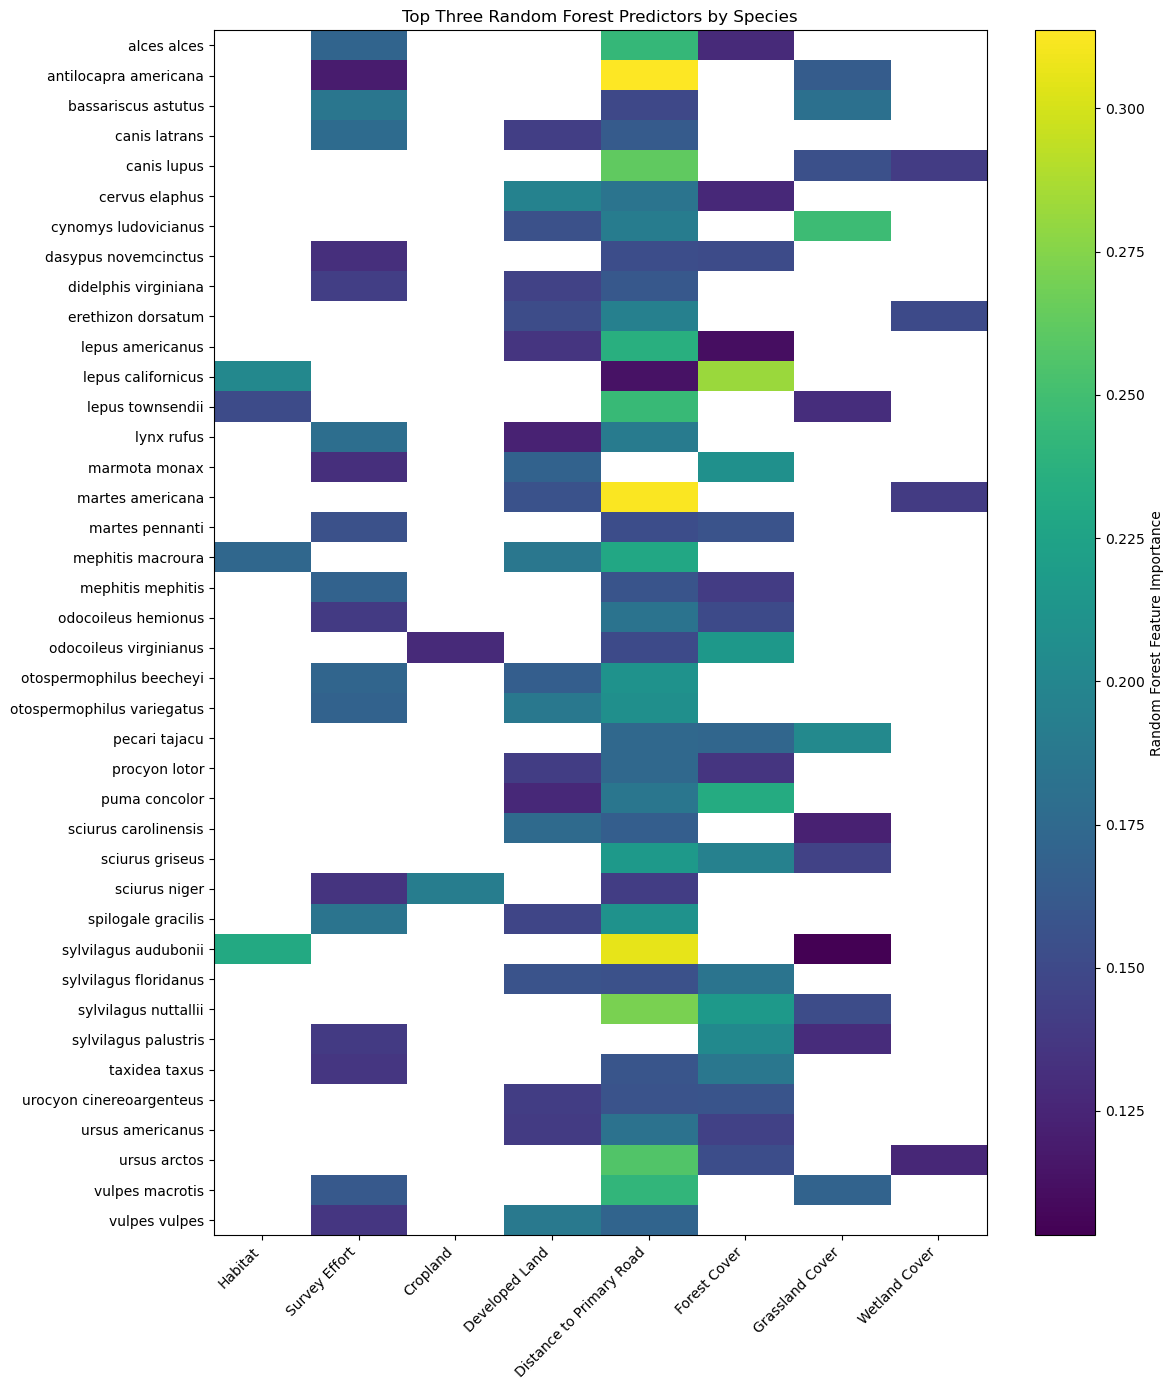

In [93]:

# ------------------------------------------------------------
# Create top-3 feature importance heatmap
# ------------------------------------------------------------

predictor_labels = {
    "distance_to_primary_road_m": "Distance to Primary Road",
    "Total_Survey_Nights": "Survey Effort",
    "forest_pct": "Forest Cover",
    "grassland_pct": "Grassland Cover",
    "wetland_pct": "Wetland Cover",
    "developed_pct": "Developed Land",
    "cropland_pct": "Cropland",
    "Habitat": "Habitat",
    "Development_Level": "Development Level"
}

importance_matrix = top3_predictors.pivot(
    index="species",
    columns="predictor",
    values="importance"
)

importance_matrix = importance_matrix.sort_index()
importance_matrix = importance_matrix.rename(
    columns=predictor_labels
)

plt.figure(figsize=(12, 14))

plt.imshow(
    importance_matrix,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Random Forest Feature Importance")

plt.xticks(
    range(len(importance_matrix.columns)),
    importance_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(importance_matrix.index)),
    importance_matrix.index
)

plt.xlabel("")
plt.ylabel("")
plt.title("Top Three Random Forest Predictors by Species")

plt.tight_layout()
plt.show()